In [78]:
source("/home/user/data2/lit/bin/lit_utils.R")
source("/home/user/data3/lit/project/sORFs/sORFs.utils.R")
lib_text()
lib_plot()
library(colorspace)

# 在质谱集合的基础上，增加frame0的比例、与其他CDS区域重叠的比例、de novo信息以及ribo-seq鉴定信息

In [73]:
orfs_path <- "../../results/augment_orf_table/augmented.tsv"
fread_c(orfs_path) -> orfs
orfs %>% filter(!grepl("Cont",ORF_id)) -> orfs
head(orfs,1)
# orfs %>% filter(ORF_length<=150) -> orfs
colnames(orfs)
count(orfs,Is_canonical)
# 制作一个通用的ORF_id_custom
paste0(orfs$Strand,orfs$Chr,":",orfs$ORF_start,"-",orfs$ORF_end,":",orfs$ORF_seq) -> orfs$ORF_id_custom
# 增加frame0的比例
fread_c("/home/user/data3/lit/project/sORFs/10-feature-egi/processed/feature_preprare/peri/psite_frame_stats.v2.tsv") -> orfs_peri
head(orfs_peri,1)
# 增加与其他CDS区域重叠的比例
fread_c("/home/user/data3/lit/project/sORFs/10-feature-egi/processed/feature_preprare/orf_overlap_inframe.txt") -> orfs_overlap
head(orfs_overlap,1)
# 增加de novo信息
fread_c("/home/user/data3/lit/project/sORFs/05-denovo-status/analysis/20251029_denovo_check/results/res_filter_paralog_ortholog.txt") -> res_filter_paralog_ortholog
head(res_filter_paralog_ortholog,1)
# 增加ribo-seq信息
read.table("/home/user/data3/lit/project/sORFs/01-ribo-seq/analysis/20251022_custom_fa_gtf/processed/orfs/merged/orfs.3_ways.txt") -> orfs.3_ways
head(orfs.3_ways,1)
fread_c("../../processed/variant_trace/_as_source.tsv") -> as_source
head(as_source,1)

,ORF_id,ORF_type,Start_codon,Isoform_id,Chr,Strand,ORF_seq,ORF_length,Geneid,Isoform_structural_category,⋯,N,C,A,Gene_type,Unique_peptide_n,Unique_peptide_n_msfragger_closed,mean_relative_iBAQ,ORF_start,ORF_end,CDS_seq
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<chr>
1,PB.10027.4:chr12:-|10|1315:112:1117|canonical|ATG,canonical,ATG,PB.10027.4,chr12,-,MATLKEKLIAPVAEEEATVPNNKITVVGVGQVGMACAISILGKSLADELALVDVLEDKLKGEMMDLQHGSLFLQTPKIVADKDYSVTANSKIVVVTAGVRQQEGESRLNLVQRNVNVFKFIIPQIVKYSPDCIIIVVSNPVDILTYVTWKLSGLPKHRVIGSGCNLDSARFRYLMAEKLGIHPSSCHGWILGEHGDSSVAVWSGVNVAGVSLQELNPEMGTDNDSENWKEVHKMVVESAYEVIKLKGYTNWAIGLSVADLIESMLKNLSRIHPVSTMVKGMYGIENEVFLSLPCILNARGLTSVINQKLKDDEVAQLKKSADTLWDIQKDLKDL,334,LDHB,full-splice_match,⋯,0.3650371,0.06854658,0.2167918,protein_coding,52,35,0.001158578,21635541,21654671,ATGGCAACTCTTAAGGAAAAACTCATTGCACCAGTTGCGGAAGAAGAGGCAACAGTTCCAAACAATAAGATCACTGTAGTGGGTGTTGGACAAGTTGGTATGGCGTGTGCTATCAGCATTCTGGGAAAGTCTCTGGCTGATGAACTTGCTCTTGTGGATGTTTTGGAAGATAAGCTTAAAGGAGAAATGATGGATCTGCAGCATGGGAGCTTATTTCTTCAGACACCTAAAATTGTGGCAGATAAAGATTATTCTGTGACCGCCAATTCTAAGATTGTAGTGGTAACTGCAGGAGTCCGTCAGCAAGAAGGGGAGAGTCGGCTCAATCTGGTGCAGAGAAATGTTAATGTCTTCAAATTCATTATTCCTCAGATCGTCAAGTACAGTCCTGATTGCATCATAATTGTGGTTTCCAACCCAGTGGACATTCTTACGTATGTTACCTGGAAACTAAGTGGATTACCCAAACACCGCGTGATTGGAAGTGGATGTAATCTGGATTCTGCTAGATTTCGCTACCTTATGGCTGAAAAACTTGGCATTCATCCCAGCAGCTGCCATGGATGGATTTTGGGGGAACATGGCGACTCAAGTGTGGCTGTGTGGAGTGGTGTGAATGTGGCAGGTGTTTCTCTCCAGGAATTGAATCCAGAAATGGGAACTGACAATGATAGTGAAAATTGGAAGGAAGTGCATAAGATGGTGGTTGAAAGTGCCTATGAAGTCATCAAGCTAAAAGGATATACCAACTGGGCTATTGGATTAAGTGTGGCTGATCTTATTGAATCCATGTTGAAAAATCTATCCAGGATTCATCCCGTGTCAACAATGGTAAAGGGGATGTATGGCATTGAGAATGAAGTCTTCCTGAGCCTTCCATGTATCCTCAATGCCCGGGGATTAACCAGCGTTATCAACCAGAAGCTAAAGGATGATGAGGTTGCTCAGCTCAAGAAAAGTGCAGATACCCTGTGGGACATCCAGAAGGACCTAAAAGACCTG


[1] "ORF_id"                            "ORF_type"                         
 [3] "Start_codon"                       "Isoform_id"                       
 [5] "Chr"                               "Strand"                           
 [7] "ORF_seq"                           "ORF_length"                       
 [9] "Geneid"                            "Isoform_structural_category"      
[11] "Isoform_subcategory"               "Is_uniprot"                       
[13] "Is_canonical"                      "Run_occurrence"                   
[15] "RPF_reads"                         "Psites_number"                    
[17] "RPF_RPKM"                          "Psites_RPKM"                      
[19] "RPF_codon_coverage"                "Psites_codon_coverage"            
[21] "FL"                                "FL_TPM"                           
[23] "N"                                 "C"                                
[25] "A"                                 "Gene_type"                        
[27] "Unique_peptide_n"                  "Unique_peptide_n_msfragger_closed"
[29] "mean_relative_iBAQ"                "ORF_start"                        
[31] "ORF_end"                           "CDS_seq"

Is_canonical,n
<lgl>,<int>
FALSE,14521
TRUE,9345


,ORF_id,CDS_nt_len,n_codons,frame0,frame1,frame2,total_psites,frame0_fraction,frame0_codon_covered
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>
1,PB.41013.1:chr6:+|1|330:5:44|noncoding|GTG,36,12,0,0,0,0,0,0


,ORF_id,overlap_bp,overlap_fraction,inframe_overlap_bp,inframe_fraction,n_annot_tx_overlapped,n_annot_gene_overlapped,top_hit_gene,top_hit_tx
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<chr>,<chr>
1,PB.41013.1:chr6:+|1|330:5:44|noncoding|GTG,0,0,0,0,0,0,,


,orf_id,ev_age,syn_age,denovo,lineage,loc_times_blat,gene_times_blastn,gene_times_blastn_pc,Outgroup Homolog,lineage_n,Outgroup Homolog n
,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>
1,PB.1001.3:chr1:-|9|2745:169:253|iORF|ACG,mammal,mammal,1,placentalia,1,1,1,human,8,1


,V1,V2,V3,V4
,<chr>,<chr>,<chr>,<chr>
1,PB.2347.5+chr1:111991157-111996513,MRDHISGCGENVNHISRISPPWAQPGHGPLKMFLIAGS,PRICE,+chr1:111991157-111996513:MRDHISGCGENVNHISRISPPWAQPGHGPLKMFLIAGS


,orf_id,pb_id,chrom,start,end,strand,associated_gene,structural_category,subcategory,AS_source,evidence
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,PB.22711.3:chr19:-|2|374:22:211|noncoding|CTG,PB.22711.3,chr19,58346858,58347554,-,A1BG,full-splice_match,alternative_5end,non_extension,CDS within transcript boundaries


In [74]:
# 合并
merge(orfs,orfs_peri) %>% merge(orfs_overlap) -> orfs_1
orfs_1 %>% head(1)
orfs_1 %>% nrow()
merge(orfs_1,res_filter_paralog_ortholog,by.x="ORF_id",by.y="orf_id",all.x = T) -> orf_2
orf_2$Ribo_seq_evidence <- ifelse(orf_2$ORF_id_custom %in% orfs.3_ways$V4,"True","False")
merge(orf_2,as_source,by.x="ORF_id",by.y="orf_id") -> orf_3

,ORF_id,ORF_type,Start_codon,Isoform_id,Chr,Strand,ORF_seq,ORF_length,Geneid,Isoform_structural_category,⋯,frame0_fraction,frame0_codon_covered,overlap_bp,overlap_fraction,inframe_overlap_bp,inframe_fraction,n_annot_tx_overlapped,n_annot_gene_overlapped,top_hit_gene,top_hit_tx
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<chr>,<chr>
1,PB.1000.1:chr1:+|33|1855:374:440|iORF|CTG,iORF,CTG,PB.1000.1,chr1,+,MAVGGAGDVDQSLQQPHQQSI,21,LURAP1,full-splice_match,⋯,0.586207,4,63,1,0,0,2,1,LURAP1,PB.1000.2


[1] 23866

In [85]:
# 导出
create_path("../../results/add_info/")
fwrite_c(orf_3,"../../results/add_info/orfs_ms_pb.txt")

# 比较经典和非经典frame0_fraction以及inframe_fraction的比例

In [77]:
orf_3 %>% group_by(Is_canonical) %>% summarise(frame0_fraction_mean=mean(frame0_fraction))
orf_3 %>% group_by(Is_canonical) %>% summarise(inframe_fraction_mean=mean(inframe_fraction))

Is_canonical,frame0_fraction_mean
<lgl>,<dbl>
FALSE,0.7314396
TRUE,0.8384210


Is_canonical,inframe_fraction_mean
<lgl>,<dbl>
FALSE,0
TRUE,1


# denovo ORF

In [79]:
get_p <- function(df){
    LEVELS <- c("human","hominoid","catarrhini","simiiformes","primates","primatomorpha","boreoeutheria",
            "placentalia","mammal")
  "lineage" -> col
  data <- data.frame(table(df[,col]))
  colnames(data) <- c(col,"Freq")
  data$lineage <- factor(data$lineage,levels=LEVELS)
  p <- ggplot(data,aes_string(x = col, y = "Freq",fill=col)) + 
    geom_bar(stat = "identity",width = 0.8) +
#     scale_y_continuous(expand = c(0, 0),limits=c(0,100)) +
    theme_3(rotate=T)+
    guides(fill = "none")
  p <- p+
    geom_text(aes(label = Freq), 
              position = position_dodge(0.8), # 确保标签对齐柱子
              vjust = -0.3,                  # 根据需要调整位置
              size = 5, color = "black")+
    coord_cartesian(clip = "off")
  p+scale_fill_discrete_divergingx() -> p
  return(p)
}

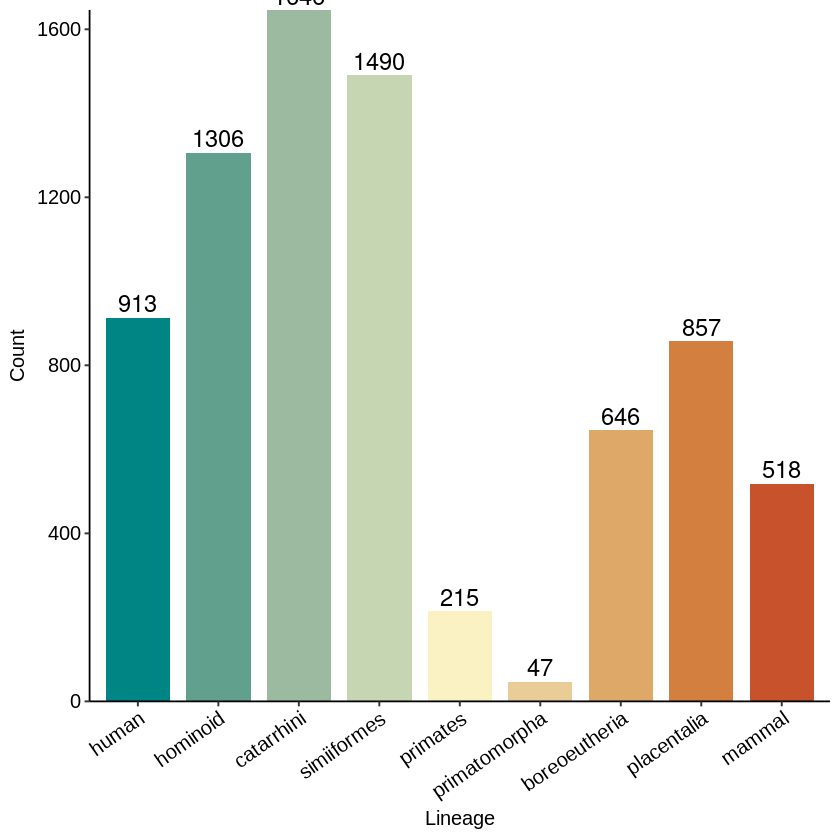

In [95]:
get_p(orf_3) + labs(x="Lineage",y="Count") + theme(plot.title=element_text(hjust=0.5,size=16))+
scale_y_continuous(expand = c(0, 0)) -> p
p
ggsave(p,filename = "../../figures/ribo_ms_noncanonical_de_novo_status.pdf",height = 5,width = 5)

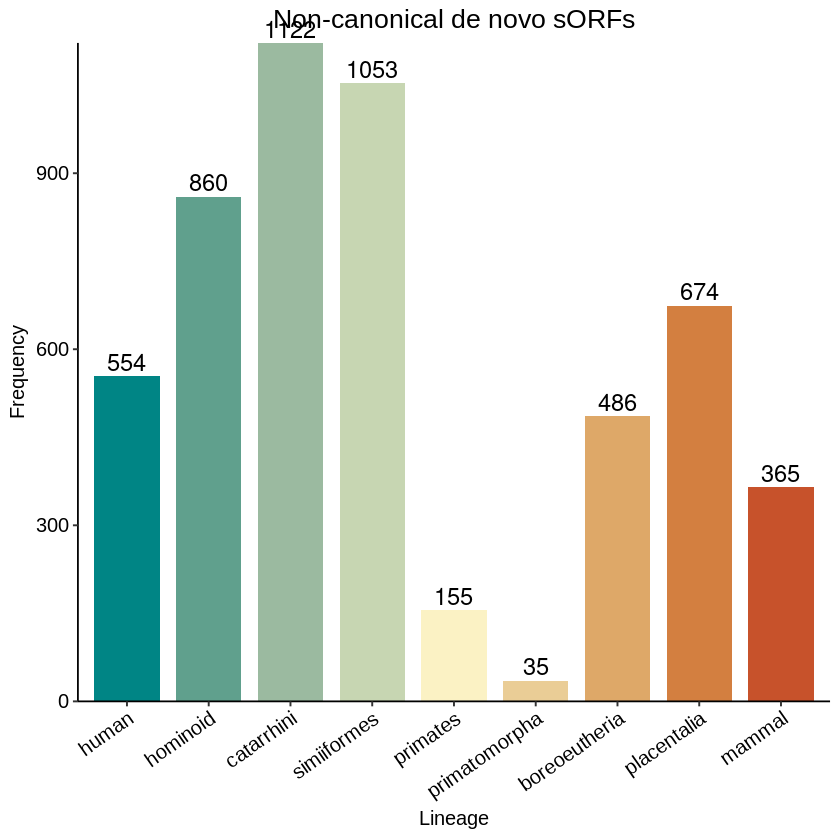

In [82]:
orf_3 %>% filter(AS_source=="non_extension") -> tmp
get_p(tmp) + labs(x="Lineage",y="Frequency",title="Non-canonical de novo sORFs") + theme(plot.title=element_text(hjust=0.5,size=16))+
scale_y_continuous(expand = c(0, 0)) -> p
p

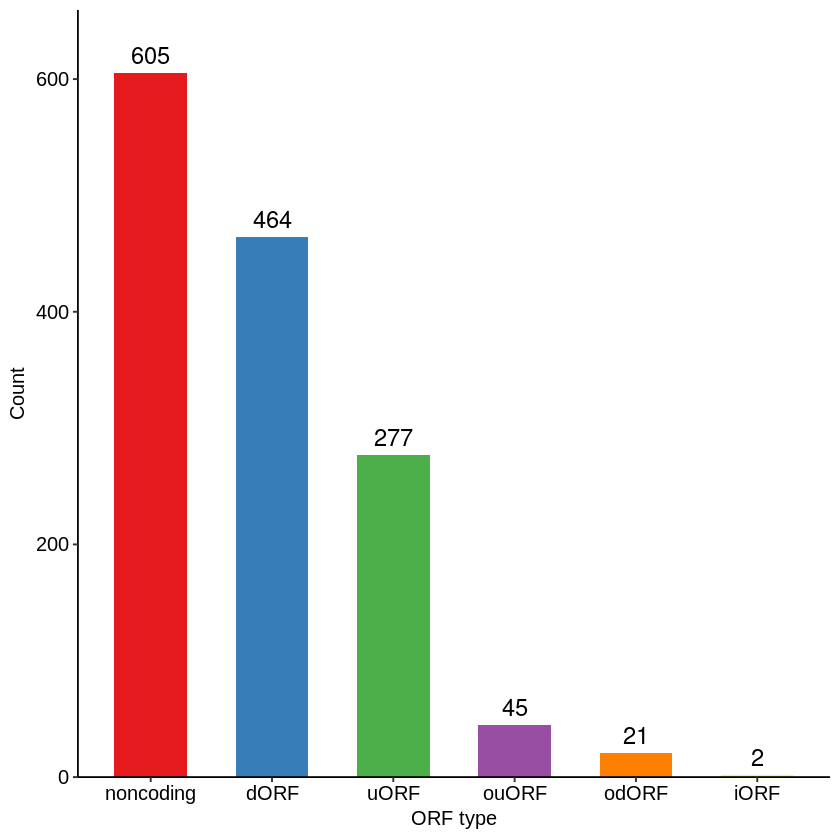

[[1]]

[[2]]

[[3]]


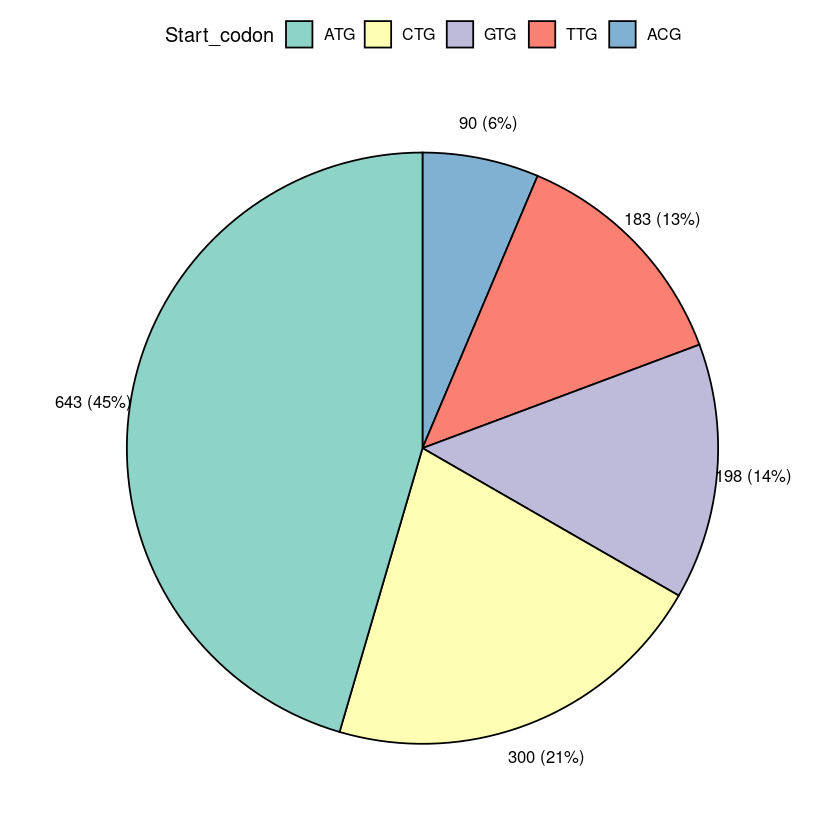

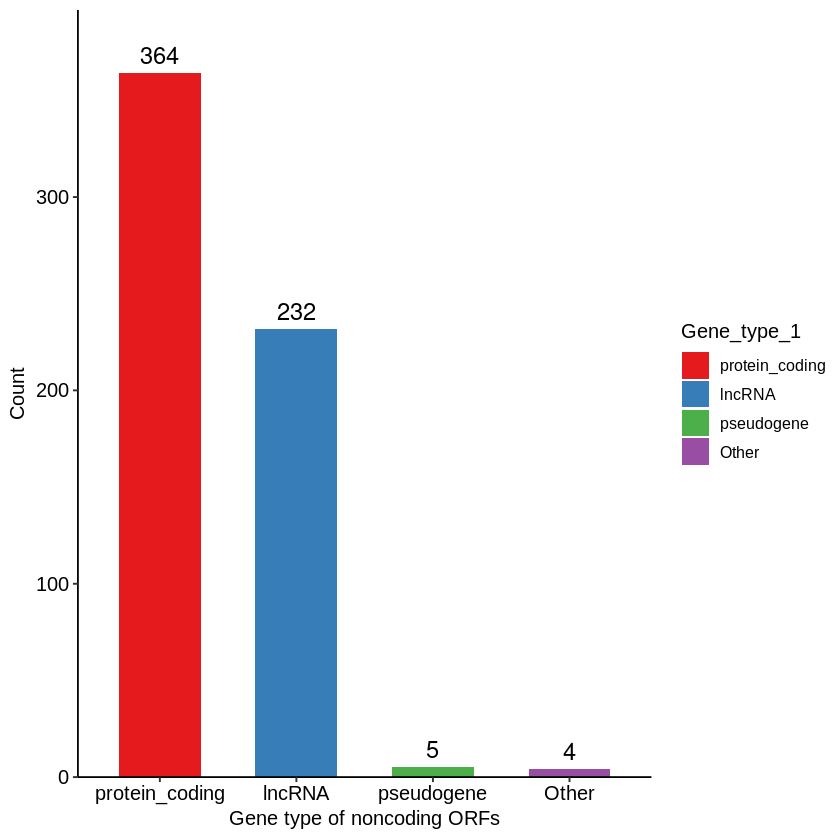

In [83]:
plot_1 <- function(df){
## 不同的ORF类型
df %>% count(ORF_type) %>% arrange(desc(n)) -> df_type_n
df_type_n$ORF_type <- factor(df_type_n$ORF_type,levels = df_type_n$ORF_type)
df_type_n %>%  bar_plot_basic(., "ORF_type","n",fil_col = "ORF_type",label = T)+
guides(fill="none")+labs(x="ORF type",y="Count")-> p1
p1
# ggsave(p1,filename = o("ORF_type.pdf"),height = 5,width = 5)

## start codon
df %>% count(Start_codon) %>% arrange(desc(n)) -> df_1
df$Start_codon <- factor(df$Start_codon,levels = df_1$Start_codon)
pie_plot(df,"Start_codon") -> p2
p2
# ggsave(p2,filename = o("scodon_type.pdf"),height = 5,width = 5)
    
filter(df, ORF_type == "noncoding") %>% 
  mutate(Gene_type_1 = case_when(
    grepl("pseudogene", Gene_type) ~ "pseudogene",
    Gene_type %in% c("Mt_rRNA", "TEC", "artifact", "misc_RNA") ~ "Other",
    TRUE ~ Gene_type
  )) %>% 
  count(Gene_type_1) %>% 
arrange(desc(n)) %>% 
mutate(Gene_type_1=factor(Gene_type_1,levels=Gene_type_1)) %>% 
bar_plot_basic(., "Gene_type_1","n",fil_col = "Gene_type_1",label = T)+
labs(x="Gene type of noncoding ORFs",y="Count") ->p3
p3
# ggsave(p,filename = o("noncodoing.orf.gene.type.pdf"),height = 5,width = 5)
    return(list(p1,p2,p3))
}
plot_1(orf_3 %>% filter(AS_source=="non_extension") %>% filter(lineage=="human"|lineage=="hominoid"))

# Ribo-seq benchmark

In [91]:
library(dplyr)

# df has columns V1, V2, V3 (software), V4 (ID string to compare)
# orf_2 has column ORF_id_custom
id_set <- unique(na.omit(as.character(orf_3$ORF_id_custom)))

res_by_sw <- orfs.3_ways %>%
  transmute(Software = as.character(V3),
            V4 = trimws(as.character(V4))) %>%
  filter(!is.na(Software), !is.na(V4), V4 != "") %>%
  distinct(Software, V4) %>%                 # deduplicate within (software, V4)
  group_by(Software) %>%
  summarise(
    n_unique_V4   = n(),                      # unique V4 per software
    n_in_orf2     = sum(V4 %in% id_set),      # hits in orf_2$ORF_id_custom
    prop_in_orf2  = if_else(n_unique_V4 > 0, n_in_orf2 / n_unique_V4, NA_real_),
    .groups = "drop"
  ) %>%
  arrange(desc(n_unique_V4))

res_by_sw

Software,n_unique_V4,n_in_orf2,prop_in_orf2
<chr>,<int>,<int>,<dbl>
RibORF,175135,12093,0.06904959
RiboCode,155561,11034,0.07093037
PRICE,18041,1179,0.06535114


# 2025-CG case

In [92]:
filter(orf_3,ORF_id=="PB.11229.2:chr12:+|26|1894:339:507|noncoding|ATG") %>% print()

                                            ORF_id  ORF_type Start_codon
1 PB.11229.2:chr12:+|26|1894:339:507|noncoding|ATG noncoding         ATG
  Isoform_id   Chr Strand
1 PB.11229.2 chr12      +
                                                  ORF_seq ORF_length    Geneid
1 MERRKSFALDQITALEGKRLQSHSFLRSAMGWDDTHLKKKKKEVTSLASLAKDMN         55 LINC02397
  Isoform_structural_category  Isoform_subcategory Is_uniprot Is_canonical
1           full-splice_match alternative_3end5end      FALSE        FALSE
  Run_occurrence RPF_reads Psites_number   RPF_RPKM Psites_RPKM
1              4        10             9 0.00400539   0.0051381
  RPF_codon_coverage Psites_codon_coverage FL   FL_TPM         N         C
1           0.181818              0.163636  9 1.230086 0.1859779 0.3611606
          A Gene_type Unique_peptide_n Unique_peptide_n_msfragger_closed
1 0.2735693    lncRNA                2                                 0
  mean_relative_iBAQ ORF_start  ORF_end
1       7.158375e-05  92482045

In [93]:
filter(orf_3,Geneid=="ZNF271P") %>% print()

                                                 ORF_id  ORF_type Start_codon
1    PB.20625.143:chr18:+|41|2394:552:747|noncoding|TTG noncoding         TTG
2 PB.20625.144:chr18:+|120|2434:2220:2313|noncoding|ATG noncoding         ATG
3    PB.20625.144:chr18:+|25|2434:449:764|noncoding|ATG noncoding         ATG
4   PB.20625.144:chr18:+|52|2434:953:1034|noncoding|GTG noncoding         GTG
    Isoform_id   Chr Strand
1 PB.20625.143 chr18      +
2 PB.20625.144 chr18      +
3 PB.20625.144 chr18      +
4 PB.20625.144 chr18      +
                                                                                                   ORF_seq
1                                         MLLERLNGATWKCGVADALWWKLTRWREESAEKSSLSSSPHSKPTQSSGPHHSALGNGAPRMPT
2                                                                           MSMKKVLISVQLLCYIKTTLDPDTYGGSRL
3 MKKIRTSLKGDLITVTNMGKALFGVQAFLGIEKRTVRNLMNGISVERPLGRNLIPVIGVLKVSVGAQTLLNTKESTLVKNLINVMSVGKPSVRAQILLYIRESI
4                                         